<a href="https://colab.research.google.com/github/LordSurov/123/blob/main/Lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа № 4
## Модель однофазной многоканальной замкнутой системы массового обслуживания

**Выполнил:** Суров ИУ5-84Б

**Вариант задания:** $m = 5$, $k = 12$



## Постановка задачи

Вычислительный центр фирмы состоит из $m = 5$ серверов (каналов обслуживания).
В отделе работают $k = 12$ программистов. Каждый программист независимо друг от
друга разрабатывает программу в течение случайного времени, распределённого
по показательному закону со средним $t_1 = 40$ мин, после чего отправляет
её на выполнение.

Если все серверы заняты, программа ставится в очередь. Программист с
нетерпением ожидает результата: если время ожидания превышает $t_3 = 15$ мин
(показательный закон), он отзывает программу и начинает писать следующую.
Время выполнения программы на сервере — показательный закон со средним
$t_2 = 20$ мин. Доход за выполнение программы составляет $S_1 = 500$ руб.,
стоимость содержания одного сервера — $S_2 = 10$ руб./мин.

**Требуется:**
1. Построить граф состояний системы.
2. Аналитически вычислить стационарные вероятности и показатели качества СМО.
3. Найти оптимальное число серверов $m^*$, максимизирующее прибыль.
4. Верифицировать результаты методом имитационного моделирования.
5. Сравнить теоретические и экспериментальные оценки.


## 1. Инициализация параметров модели

В соответствии с вариантом задания устанавливаются следующие числовые параметры
системы (таблица 1).

**Таблица 1 — Исходные данные**

| Параметр | Обозначение | Значение | Размерность |
|---|---|---|---|
| Число серверов | $m$ | 5 | — |
| Число программистов | $k$ | 12 | — |
| Среднее время подготовки программы | $t_1$ | 40 | мин |
| Среднее время выполнения на сервере | $t_2$ | 20 | мин |
| Среднее время терпения в очереди | $t_3$ | 15 | мин |
| Доход за обслуженную заявку | $S_1$ | 500 | руб. |
| Стоимость содержания сервера | $S_2$ | 10 | руб./мин |

Базовые интенсивности вычисляются как:
$$\lambda = 1/t_1, \quad \mu = 1/t_2, \quad \nu = 1/t_3.$$

In [ ]:
# Параметры задачи
m  <- 5       # число серверов
k  <- 12      # число программистов
t1 <- 40      # среднее время подготовки (мин)
t2 <- 20      # среднее время выполнения (мин)
t3 <- 15      # среднее время ожидания до отзыва (мин)
S1 <- 500     # плата за обслуженную заявку (руб)
S2 <- 10      # стоимость сервера (руб/мин)

lambda_val <- 1 / t1   # интенсивность подготовки программы
mu_val     <- 1 / t2   # интенсивность выполнения на сервере
nu_val     <- 1 / t3   # интенсивность отзыва из очереди

cat(sprintf("lambda = 1/t1 = %.4f (1/мин)\n", lambda_val))
cat(sprintf("mu     = 1/t2 = %.4f (1/мин)\n", mu_val))
cat(sprintf("nu     = 1/t3 = %.4f (1/мин)\n", nu_val))

lambda = 1/t1 = 0.0250 (1/мин)
mu     = 1/t2 = 0.0500 (1/мин)
nu     = 1/t3 = 0.0667 (1/мин)


**Результат инициализации.**
Введены три базовые интенсивности:
$\lambda = 1/t_1 = 0{,}025$ (1/мин), $\mu = 1/t_2 = 0{,}05$ (1/мин),
$\nu = 1/t_3 = 0{,}\overline{06}$ (1/мин).
Поскольку $\lambda < \mu$, сервер в среднем выполняет программы быстрее,
чем программисты их подготавливают.
Параметр $\nu$ характеризует нетерпение: при ожидании сверх $t_3$ мин
программист отзывает заявку и начинает подготовку следующей программы.

## 2. Граф состояний системы

Состояние системы определяется числом программ $n$, находящихся в системе
(на серверах и в очереди), $n = 0, 1, \ldots, k$.

Поскольку все случайные величины имеют показательное распределение,
процесс является марковской цепью  с $k+1 = 13$
состояниями. Интенсивности переходов определяются формулами (1) и (2):

$$\lambda_n = (k - n)\cdot\lambda, \quad n = 0, 1, \ldots, k-1, \tag{1}$$

$$\mu_n = \begin{cases} n\cdot\mu, & 0 < n \leq m, \\ m\cdot\mu + (n-m)\cdot\nu, & n > m. \end{cases} \tag{2}$$

При $n > m$ в очереди находятся $n - m$ нетерпеливых заявок, каждая из
которых покидает систему с интенсивностью $\nu$.
Стрелки на рисунке 1 обозначают:
**синие** (верхние) — переходы поступления $(S_n \to S_{n+1})$;
**красные** (нижние) — переходы ухода $(S_n \to S_{n-1})$.

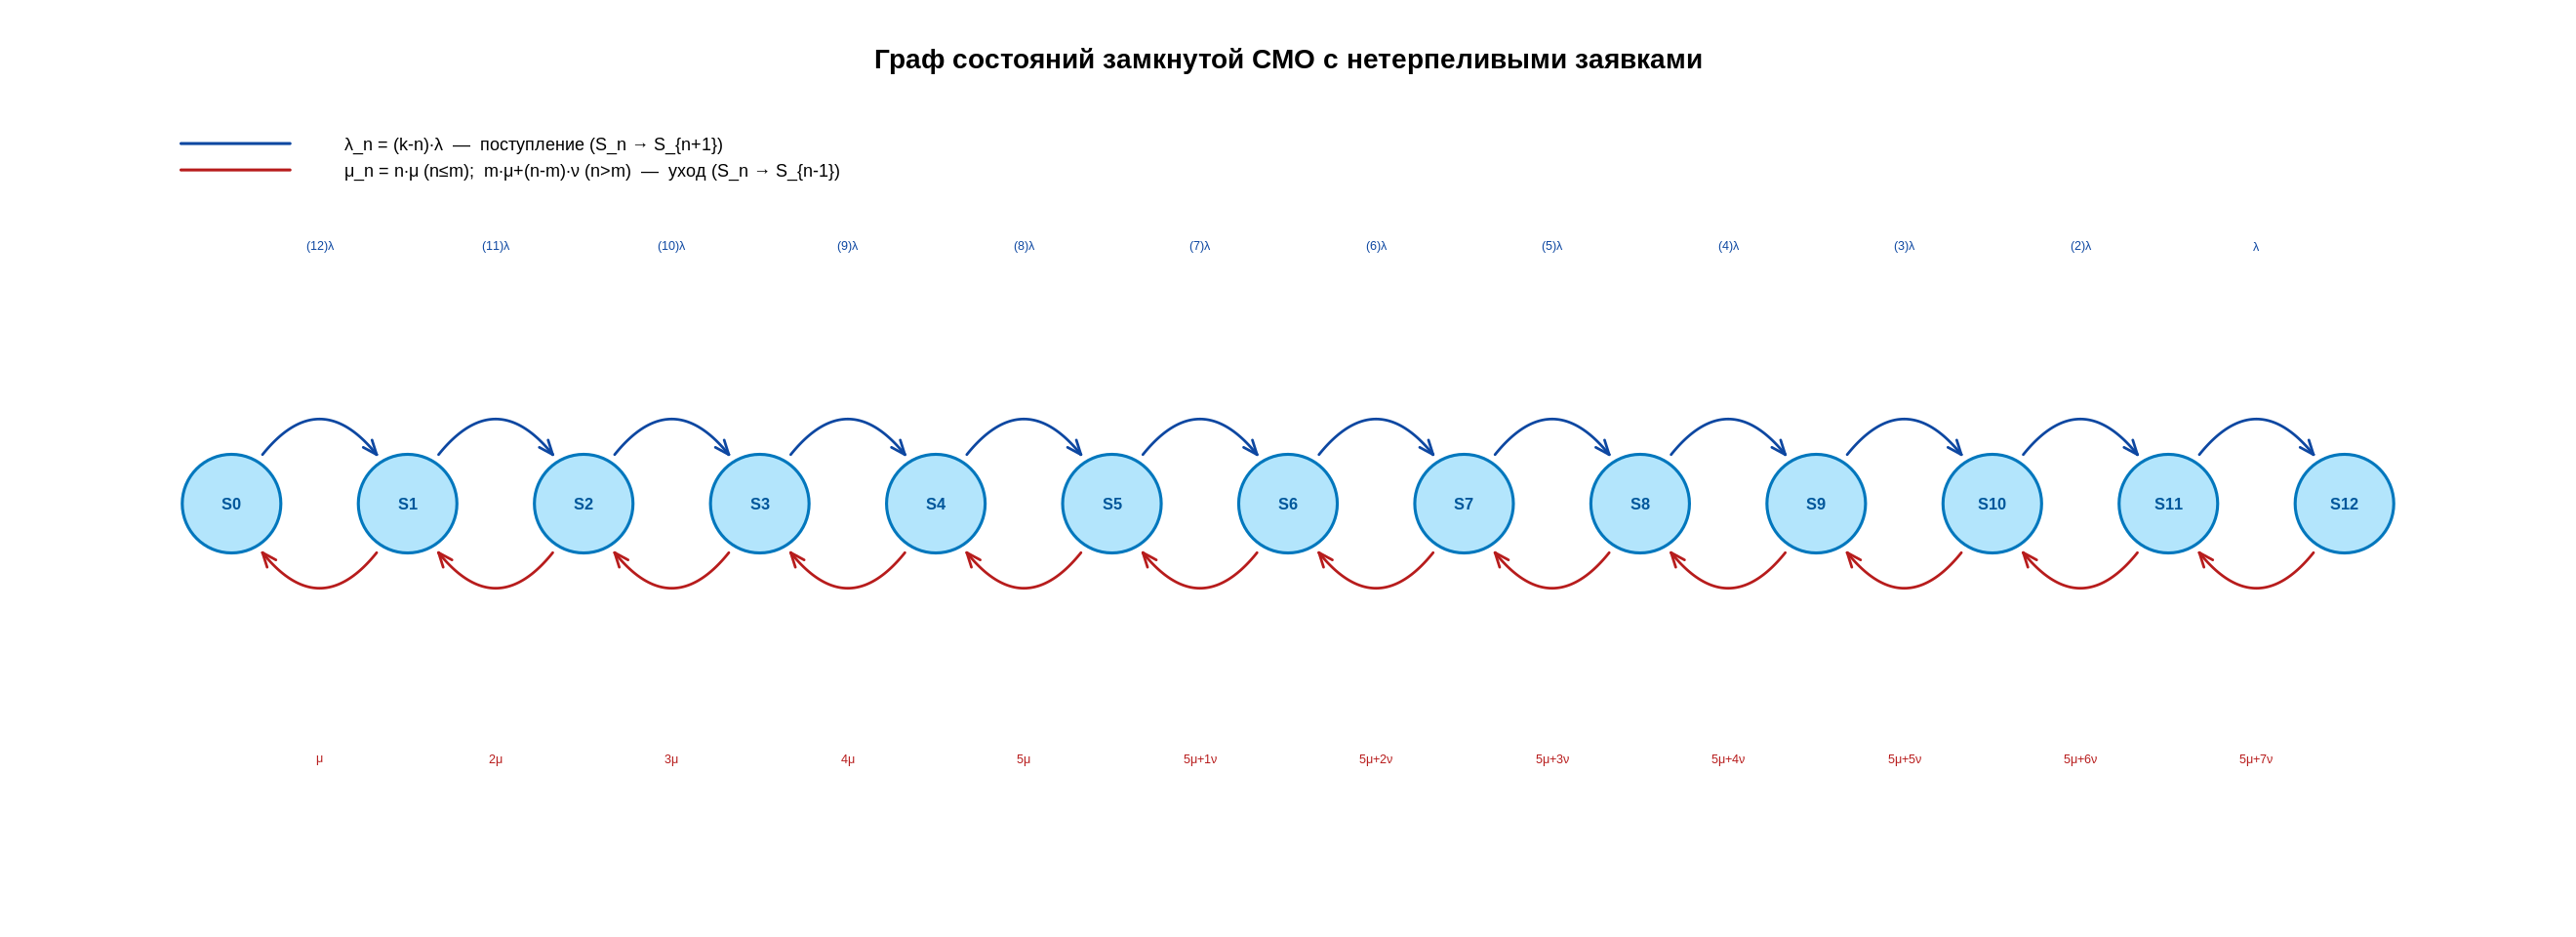

In [ ]:
# ============================================================
# Построение графа состояний
# ============================================================

options(repr.plot.width = 22, repr.plot.height = 8)
par(mar = c(2, 1, 5, 1), bg = "white")

# --- функция: квадратичная кривая Безье + наконечник стрелки ---
draw_bezier_arrow <- function(x1, x2, y_ctrl, col_line, label_txt, r = 0.28) {
  n_pts <- 200
  t     <- seq(0, 1, length.out = n_pts)
  xm    <- (x1 + x2) / 2

  # квадратичный Безье: оба конца на y = 0, пик в y_ctrl
  x_b <- (1 - t)^2 * x1 + 2*(1 - t)*t * xm + t^2 * x2
  y_b <- 2*(1 - t)*t * y_ctrl

  # убираем точки внутри узловых кругов
  d_start <- sqrt((x_b - x1)^2 + y_b^2)
  d_end   <- sqrt((x_b - x2)^2 + y_b^2)
  idx     <- which(d_start > r & d_end > r)

  if (length(idx) > 4) {
    xd <- x_b[idx]; yd <- y_b[idx]
    lines(xd, yd, col = col_line, lwd = 2.2)
    nd <- length(xd)
    arrows(xd[nd - 4], yd[nd - 4], xd[nd], yd[nd],
           col = col_line, lwd = 2.2, length = 0.13, angle = 22, code = 2)
  }
  text(xm, y_ctrl * 1.52, label_txt, cex = 0.63, col = col_line)
}

# --- параметры ---
r_node <- 0.28
y_fwd  <-  0.78
y_bwd  <- -0.78

# --- пустой холст ---
plot(NULL,
     xlim = c(-0.65, k + 0.65), ylim = c(-1.65, 1.65),
     xlab = "", ylab = "", axes = FALSE,
     main = "\u0413\u0440\u0430\u0444 \u0441\u043e\u0441\u0442\u043e\u044f\u043d\u0438\u0439 \u0437\u0430\u043c\u043a\u043d\u0443\u0442\u043e\u0439 \u0421\u041c\u041e \u0441 \u043d\u0435\u0442\u0435\u0440\u043f\u0435\u043b\u0438\u0432\u044b\u043c\u0438 \u0437\u0430\u044f\u0432\u043a\u0430\u043c\u0438",
     cex.main = 1.4)

# --- синие дуги: S_n -> S_{n+1}  (lambda_n = (k-n)*lambda) ---
for (n in 0:(k - 1)) {
  lbl <- if (k - n == 1) "\u03bb" else paste0("(", k - n, ")\u03bb")
  draw_bezier_arrow(n, n + 1, y_fwd, "#0D47A1", lbl, r = r_node)
}

# --- красные дуги: S_n -> S_{n-1}  (mu_n или m*mu + (n-m)*nu) ---
for (n in 1:k) {
  lbl <- if (n <= m) {
    if (n == 1) "\u03bc" else paste0(n, "\u03bc")
  } else {
    paste0(m, "\u03bc+", n - m, "\u03bd")
  }
  draw_bezier_arrow(n, n - 1, y_bwd, "#B71C1C", lbl, r = r_node)
}

# --- узлы поверх дуг ---
for (n in 0:k) {
  symbols(n, 0, circles = r_node, add = TRUE,
          fg = "#0277BD", bg = "#B3E5FC", inches = FALSE, lwd = 2.5)
  text(n, 0, paste0("S", n), cex = 0.82, col = "#01579B", font = 2)
}

# --- легенда ---
legend("topright",
       legend = c(
         "\u03bb_n = (k-n)\u00b7\u03bb  \u2014  \u043f\u043e\u0441\u0442\u0443\u043f\u043b\u0435\u043d\u0438\u0435 (S_n \u2192 S_{n+1})",
         "\u03bc_n = n\u00b7\u03bc (n\u2264m);  m\u00b7\u03bc+(n-m)\u00b7\u03bd (n>m)  \u2014  \u0443\u0445\u043e\u0434 (S_n \u2192 S_{n-1})"
       ),
       col  = c("#0D47A1", "#B71C1C"),
       lty  = 1, lwd  = 2.5, bty  = "n", cex  = 0.90)

**Рисунок 1 — Граф состояний замкнутой СМО**

Граф представляет собой цепь рождения-гибели с $k + 1 = 13$ состояниями
$S_0, S_1, \ldots, S_{12}$.

- Интенсивность поступления $\lambda_n = (k-n)\lambda$ убывает с ростом $n$:
  чем больше программ в системе, тем меньше свободных программистов.
- При $n \leq m = 5$ все поступившие программы немедленно получают сервер;
  интенсивность ухода $\mu_n = n\mu$.
- При $n > 5$ часть программ ожидает в очереди;
  интенсивность ухода $\mu_n = m\mu + (n-m)\nu$ учитывает как
  завершение обслуживания, так и отзыв нетерпеливых заявок.

Построенный граф является исходным для составления системы уравнений
глобального баланса.

## 3. Теоретическое решение

### 3.1. Стационарные вероятности состояний

Для нашего процесса система уравнений глобального баланса
редуцируется к рекуррентному соотношению:

$$P(n) = P(0) \cdot \prod_{i=0}^{n-1} \frac{\lambda_i}{\mu_{i+1}},
\quad n = 1, 2, \ldots, k. \tag{3}$$

Вероятность $P(0)$ определяется из условия нормировки:

$$\sum_{n=0}^{k} P(n) = 1
\implies
$$

$$
P(0)=\frac{1}{1+\sum_{n=1}^{k}\prod_{i=0}^{n-1}\frac{\lambda_i}{\mu_{i+1}}}.
\tag{4}
$$

Вычисление производится последовательно: сначала находятся все
произведения $\rho_n$, затем $P(0)$, затем все $P(n)$.

In [ ]:
# Вычисление финальных вероятностей

# Интенсивности поступления: lambda_n = (k - n) * lambda, n = 0, ..., k-1
lam_n <- (k - 0:(k-1)) * lambda_val

# Интенсивности ухода: mu_n для n = 1, ..., k
mu_n <- sapply(1:k, function(n) {
  if (n <= m) n * mu_val
  else m * mu_val + (n - m) * nu_val
})

cat(sprintf("Интенсивности поступления lambda_n (n=0..%d):\n", k-1))
print(round(lam_n, 4))
cat(sprintf("\nИнтенсивности ухода mu_n (n=1..%d):\n", k))
print(round(mu_n, 4))

# Вычисляем произведения rho_n = prod(lambda_i / mu_{i+1}, i=0..n-1)
rho <- numeric(k)
rho[1] <- lam_n[1] / mu_n[1]
for (n in 2:k) {
  rho[n] <- rho[n-1] * lam_n[n] / mu_n[n]
}

# P(0)
P0 <- 1 / (1 + sum(rho))

# Все вероятности
P <- c(P0, P0 * rho)
names(P) <- paste0("P(", 0:k, ")")

cat("\nФинальные вероятности:\n")
for (n in 0:k) {
  cat(sprintf("  P(%2d) = %.6f\n", n, P[n + 1]))
}
cat(sprintf("\nПроверка: сумма = %.10f\n", sum(P)))

Интенсивности поступления lambda_n (n=0..11):
 [1] 0.300 0.275 0.250 0.225 0.200 0.175 0.150 0.125 0.100 0.075 0.050 0.025

Интенсивности ухода mu_n (n=1..12):
 [1] 0.0500 0.1000 0.1500 0.2000 0.2500 0.3167 0.3833 0.4500 0.5167 0.5833
[11] 0.6500 0.7167

Финальные вероятности:
  P( 0) = 0.007841
  P( 1) = 0.047047
  P( 2) = 0.129380
  P( 3) = 0.215633
  P( 4) = 0.242587
  P( 5) = 0.194069
  P( 6) = 0.107249
  P( 7) = 0.041967
  P( 8) = 0.011657
  P( 9) = 0.002256
  P(10) = 0.000290
  P(11) = 0.000022
  P(12) = 0.000001

Проверка: сумма = 1.0000000000


**Результат.**
Вычислены стационарные вероятности $P(n)$ для всех состояний
$n = 0, 1, \ldots, 12$. Выполнена проверка условия нормировки:
$\sum_{n=0}^{k} P(n) = 1$.
Максимальные значения сосредоточены в окрестности $n \approx m$,
что соответствует режиму полной загрузки серверов при отсутствии
существенной очереди.

### 3.2. Распределение стационарных вероятностей

На рисунке 2 представлена гистограмма стационарного распределения $P(n)$
по состояниям $n = 0, 1, \ldots, k$. Форма распределения позволяет оценить
наиболее вероятное число программ в системе в установившемся режиме.

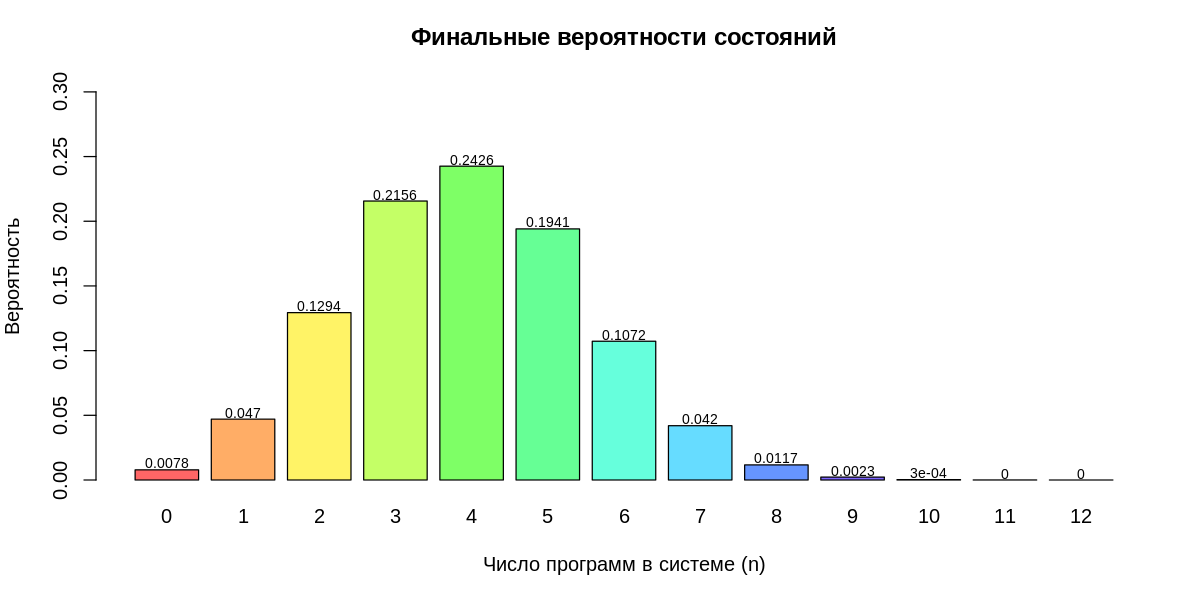

In [ ]:
# Визуализация финальных вероятностей
options(repr.plot.width = 10, repr.plot.height = 5)
par(mar = c(5, 4, 3, 2))
bp <- barplot(P, col = rainbow(k + 1, s = 0.6),
              main = "Финальные вероятности состояний",
              ylab = "Вероятность", xlab = "Число программ в системе (n)",
              names.arg = 0:k, ylim = c(0, max(P) * 1.3))
text(bp, P + 0.005, labels = round(P, 4), cex = 0.7)

**Рисунок 2 — Распределение стационарных вероятностей $P(n)$**

Система крайне редко находится в состоянии полного простоя ($n = 0$)
или максимальной загрузки ($n = k = 12$).
Наибольшие вероятности приходятся на состояния $n \approx m = 5$,
что подтверждает: серверы большую часть времени полностью загружены,
а длина очереди незначительна.
Ненулевые значения при $n > m$ свидетельствуют о периодическом
образовании очереди с последующим отзывом нетерпеливых заявок.

### 3.3. Показатели качества СМО

По найденным стационарным вероятностям вычисляются четыре основных
характеристики эффективности системы (таблица 2).

**Таблица 2 — Аналитические формулы показателей качества**

| Показатель | Обозначение | Формула |
|---|---|---|
| Вероятность ожидания | $P_\text{ожид}$ | $\displaystyle\frac{\sum_{n=m}^{k-1}(k-n)\lambda P(n)}{\sum_{n=0}^{k-1}(k-n)\lambda P(n)}$ |
| Среднее число заявок в очереди | $L_q$ | $\displaystyle\sum_{n=m+1}^{k}(n-m)P(n)$ |
| Абсолютная пропускная способность | $A$ | $\displaystyle\sum_{n=1}^{k}\min(n,m)\cdot\mu\cdot P(n)$ |
| Среднее время пребывания | $W$ | $L_\text{сист}/\Lambda$ (закон Литтла) |


Вероятность того, что поступившая программа не будет выполнена сразу, определяется как отношение интенсивности поступлений в состояния, где все m каналов уже заняты, к общей интенсивности всех поступлений в систему.

Среднее число программ в системе находится как математическое ожидание числа программ в системе. Если система находится в состоянии n с вероятностью P(n), то среднее число программ равно сумме nP(n) по всем состояниям.

Среднее время пребывания программы в системе определяется по формуле Литтла как отношение среднего числа программ в системе к средней интенсивности поступления.

Среднее число программ в очереди находится как математическое ожидание длины очереди. В состоянии n в очереди находится n-m программ, если n>m, и 0, если n\le m.

“Абсолютная пропускная способность — это среднее число программ, обслуживаемых системой в единицу времени. В состоянии n обслуживается min(n,m) программ, каждая с интенсивностью \mu, поэтому вклад этого состояния равен min(n,m)\mu P(n)

In [ ]:
# 1. Вероятность того, что программа не будет выполнена сразу
#    P_wait = sum_{n=m}^{k-1} P(n)*(k-n) / sum_{n=0}^{k-1} P(n)*(k-n)
numerator   <- sum(P[(m+1):k] * (k - m:(k-1)))
denominator <- sum(P[1:k] * (k - 0:(k-1)))
P_wait <- numerator / denominator
cat(sprintf("1. P(программа не будет обслужена сразу) = %.6f", P_wait))

# 2. Среднее число программ в системе и время пребывания
L_sys <- sum(0:k * P)
Lambda_in <- sum(sapply(0:(k-1), function(n) (k - n) * lambda_val * P[n + 1]))
W_sys <- L_sys / Lambda_in
cat(sprintf("2. Среднее время до получения результатов: W = %.4f мин", W_sys))

# 3. Среднее число программ в очереди
L_queue <- sum(sapply(0:k, function(n) max(0, n - m) * P[n + 1]))
cat(sprintf("3. Среднее число программ в очереди: Lq = %.6f", L_queue))

# 4. Абсолютная пропускная способность
A <- sum(sapply(1:k, function(n) min(n, m) * mu_val * P[n + 1]))
cat(sprintf("4. Абсолютная пропускная способность: A = %.6f (прог/мин)", A))

cat("
--- Дополнительные характеристики ---
")
cat(sprintf("   L_sys (среднее число в системе) = %.6f
", L_sys))
cat(sprintf("   Lambda (средняя интенс. входа)  = %.6f (прог/мин)
", Lambda_in))


1. P(программа не будет обслужена сразу) = 0.2813762. Среднее время до получения результатов: W = 19.6080 мин3. Среднее число программ в очереди: Lq = 0.2367704. Абсолютная пропускная способность: A = 0.185531 (прог/мин)
--- Дополнительные характеристики ---
   L_sys (среднее число в системе) = 3.947384
   Lambda (средняя интенс. входа)  = 0.201315 (прог/мин)


**Таблица 3 — Теоретические значения показателей качества**

Результаты расчёта по формулам раздела 3.3 приведены в выводе ячейки выше.

- **$P_\text{ожид}$** — доля заявок, не получивших свободный сервер
  немедленно; характеризует степень загруженности системы.
- **$W$** — среднее время от момента подачи программы до получения
  результата; включает ожидание в очереди и время выполнения.
- **$L_q$** — среднее число заявок, одновременно ожидающих
  в очереди; при $L_q \approx 0$ очередь практически отсутствует.
- **$A$** — реальная производительность системы с учётом
  нетерпеливых заявок; используется при оптимизации прибыли.

Полученные аналитические значения будут верифицированы
методом имитационного моделирования в разделе 4.

### 3.4. Оптимизация числа серверов по критерию максимума прибыли

Целевая функция — прибыль в единицу времени:

$$\Pi(m) = A(m) \cdot S_1 - m \cdot S_2, \tag{5}$$

где $A(m)$ — абсолютная пропускная способность при числе серверов $m$;
$S_1 = 500$ руб. — доход за одну выполненную программу;
$S_2 = 10$ руб./мин — стоимость содержания одного сервера.

Для нахождения $m^* = \arg\max_{m}\,\Pi(m)$ выполняется полный перебор
$m = 1, 2, \ldots, k$: для каждого значения пересчитываются стационарные
вероятности и вычисляется $\Pi(m)$.

> **Замечание.** При малом $m$ нетерпеливые заявки покидают очередь,
> $A(m)$ мало, прибыль низкая. При большом $m$ часть серверов простаивает,
> расходы $m \cdot S_2$ превышают прирост дохода.

In [ ]:
# Функция расчёта характеристик СМО для произвольного m
calc_smo <- function(m_val, k_val, lambda_v, mu_v, nu_v) {
  lam_n_loc <- (k_val - 0:(k_val-1)) * lambda_v
  mu_n_loc  <- sapply(1:k_val, function(n) {
    if (n <= m_val) n * mu_v
    else m_val * mu_v + (n - m_val) * nu_v
  })
  rho_loc <- numeric(k_val)
  rho_loc[1] <- lam_n_loc[1] / mu_n_loc[1]
  for (n in 2:k_val) rho_loc[n] <- rho_loc[n-1] * lam_n_loc[n] / mu_n_loc[n]
  P0_loc  <- 1 / (1 + sum(rho_loc))
  P_loc   <- c(P0_loc, P0_loc * rho_loc) # получили стац вероятности
  A_val <- sum(sapply(1:k_val, function(n) min(n, m_val) * mu_v * P_loc[n + 1]))
  list(A = A_val, P = P_loc)
}

# Перебираем m от 1 до k
m_range <- 1:k
profits <- numeric(length(m_range))
A_vals  <- numeric(length(m_range))

cat(sprintf("%4s %14s %18s
", "m", "A (прог/мин)", "Прибыль (руб/мин)"))
cat(strrep("-", 40), "
")

for (i in seq_along(m_range)) {
  res <- calc_smo(m_range[i], k, lambda_val, mu_val, nu_val)
  A_vals[i] <- res$A
  profits[i] <- res$A * S1 - m_range[i] * S2
  cat(sprintf("%4d %14.6f %18.4f
", m_range[i], A_vals[i], profits[i]))
}

m_opt <- m_range[which.max(profits)]
cat(sprintf("
Оптимальное число серверов: m* = %d
", m_opt))
cat(sprintf("Максимальная прибыль: %.4f руб/мин
", max(profits)))


   m A (прог/мин) Прибыль (руб/мин)
---------------------------------------- 
   1       0.049341            14.6706
   2       0.095961            27.9806
   3       0.136251            38.1256
   4       0.166565            43.2826
   5       0.185531            42.7654
   6       0.195014            37.5071
   7       0.198680            29.3401
   8       0.199743            19.8714
   9       0.199965             9.9826
  10       0.199997            -0.0014
  11       0.200000           -10.0001
  12       0.200000           -20.0000

Оптимальное число серверов: m* = 4
Максимальная прибыль: 43.2826 руб/мин


**Результат оптимизации.**
Таблица выше содержит значения $A(m)$ и $\Pi(m)$ для всех
$m = 1, \ldots, k$. Оптимальное число серверов $m^*$ соответствует
строке с максимальным значением прибыли.

При $m < m^*$ нетерпеливые заявки массово покидают очередь:
$A(m)$ существенно ниже своего максимума.
При $m > m^*$ пропускная способность практически не растёт,
тогда как расходы на содержание серверов увеличиваются линейно.

## 4. Имитационное моделирование

Для верификации аналитических результатов проводится дискретно-событийное
моделирование (Discrete-Event Simulation, DES) системы.
Применяется метод «следующего события» (next-event time advance).

**Таблица 4 — Типы событий модели**

| Событие | Условие | Действие |
|---|---|---|
| `submit` | Программист завершил подготовку программы | Передача на сервер или постановка в очередь |
| `server_done` | Сервер завершил выполнение | Освобождение сервера, извлечение следующей заявки |
| `impatient` | Истёк дедлайн ожидания заявки в очереди | Удаление из очереди, программист начинает новую |

Длительность моделирования $T = 500\,000$ мин обеспечивает статистическую
погрешность порядка $O(1/\sqrt{T}) \approx 0{,}001$, что достаточно для
сравнения с аналитическими результатами.

### 4.1. Инициализация симуляции

Начальное состояние системы: все $k = 12$ программистов готовят программы,
$m = 5$ серверов свободны, очередь пуста.
Генератор псевдослучайных чисел инициализируется значением `seed = 42`
для обеспечения воспроизводимости результатов.

Для оценки средних длин очереди ведутся интегральные накопители:
$\displaystyle\int_0^T L_q(t)\,dt$

In [ ]:
set.seed(42)  # Фиксируем генератор случайных чисел для воспроизводимости.

T_total <- 500000  # Общее модельное время в минутах.

prog_state <- rep("writing", k)  # В начале все программисты пишут программу.
prog_event <- rexp(k, lambda_val)  # Время до завершения подготовки программы для каждого программиста.
prog_submit_time <- rep(0, k)  # Моменты отправки программ в систему.

server_busy_until <- rep(0, m)  # До какого времени занят каждый сервер.
server_prog <- rep(0, m)  # Какая программа сейчас обслуживается на каждом сервере.

queue <- list()  # Очередь ожидающих программ.

total_served <- 0  # Число выполненных программ.
total_submitted <- 0  # Число поступивших программ.
total_impatient <- 0  # Число программ, ушедших из очереди из-за нетерпения.
total_service_time <- 0  # Суммарное время пребывания обслуженных программ в системе.
integral_queue <- 0  # Накопитель для среднего числа программ в очереди.
integral_system <- 0  # Накопитель для среднего числа программ в системе.
total_not_immediate <- 0  # Число программ, не попавших на сервер сразу.

t_cur <- 0  # Текущее модельное время.

get_queue_len <- function() length(queue)  # Текущая длина очереди.
get_n_busy <- function() sum(server_busy_until > t_cur)  # Число занятых серверов.
get_n_system <- function() get_n_busy() + get_queue_len()  # Общее число программ в системе.

cat("Запуск имитационного моделирования...\n")  # Сообщение о старте симуляции.

Запуск имитационного моделирования...


**Результат инициализации.**
Симулятор настроен: $k = 12$ программистов, $m = 5$ серверов.
Все структуры данных (очередь, список серверов, таймеры программистов)
приведены в начальное состояние. Интегральные накопители обнулены.

### 4.2. Основной цикл дискретно-событийного моделирования

На каждой итерации цикла выполняются следующие шаги:

1. Определяется ближайшее по времени событие среди всех активных
   программистов, серверов и заявок в очереди.
2. Интегральные накопители $\int L_q\,dt$ и $\int L_s\,dt$ обновляются
   пропорционально длине прошедшего интервала $\Delta t$.
3. Событие обрабатывается, для соответствующего актора генерируется
   следующее событие.

Цикл завершается, когда время ближайшего события превышает $T_{\text{total}}$.

In [ ]:
# Основной цикл дискретно-событийного моделирования
while (t_cur < T_total) {
  next_time <- Inf; next_type <- ""; next_id <- 0

  for (i in 1:k) {
    if (prog_state[i] == "writing" && prog_event[i] < next_time) { # Ищем: кто первым закончит писать программу.
      next_time <- prog_event[i]; next_type <- "submit"; next_id <- i
    }
  }
  for (j in 1:m) {
    if (server_busy_until[j] > t_cur && server_busy_until[j] < next_time) { # Ищем: какой сервер первым закончит выполнение программы.
      next_time <- server_busy_until[j]; next_type <- "server_done"; next_id <- j
    }
  }
  if (length(queue) > 0) {
    for (q in seq_along(queue)) { # Ищем: какая заявка первой не дождётся обслуживания.
      if (queue[[q]]$deadline < next_time) {
        next_time <- queue[[q]]$deadline; next_type <- "impatient"; next_id <- q
      }
    }
  }

  if (next_time >= T_total) break

  dt <- next_time - t_cur # Это время между текущим моментом и следующим событием:
  integral_queue  <- integral_queue  + get_queue_len() * dt
  t_cur <- next_time

  if (next_type == "submit") {
    total_submitted <- total_submitted + 1
    prog_state[next_id] <- "waiting"
    prog_submit_time[next_id] <- t_cur
    free_srv <- which(server_busy_until <= t_cur)
    if (length(free_srv) > 0) {
      srv <- free_srv[1]
      svc_time <- rexp(1, mu_val)
      server_busy_until[srv] <- t_cur + svc_time
      server_prog[srv] <- next_id
      prog_state[next_id] <- "served"
      prog_event[next_id] <- t_cur + svc_time
    } else {
      total_not_immediate <- total_not_immediate + 1
      patience <- rexp(1, nu_val)
      queue[[length(queue) + 1]] <- list(
        prog_id = next_id, deadline = t_cur + patience, submit_time = t_cur)
    }

  } else if (next_type == "server_done") {
    srv <- next_id; pid <- server_prog[srv]
    if (pid > 0) {
      total_served <- total_served + 1
      total_service_time <- total_service_time + (t_cur - prog_submit_time[pid])
      prog_state[pid] <- "writing" # Программа выполнена, пользователь получил результат, программист пошёл делать следующую.
      prog_event[pid] <- t_cur + rexp(1, lambda_val) # назначить время выполнения следующей программы
    }
    if (length(queue) > 0) { # Освободившийся сервер сразу берёт следующую программу из очереди.
      item <- queue[[1]]; queue <- queue[-1]
      svc_time <- rexp(1, mu_val)
      server_busy_until[srv] <- t_cur + svc_time
      server_prog[srv] <- item$prog_id
      prog_state[item$prog_id] <- "served"
      prog_event[item$prog_id] <- t_cur + svc_time
      prog_submit_time[item$prog_id] <- item$submit_time
    } else {
      server_busy_until[srv] <- 0; server_prog[srv] <- 0 # Сервер просто становится свободным.
    }

  } else if (next_type == "impatient") { # Это случай, когда программа слишком долго ждала и ушла из очереди.
    item <- queue[[next_id]]; queue <- queue[-next_id]
    total_impatient <- total_impatient + 1
    prog_state[item$prog_id] <- "writing"
    prog_event[item$prog_id] <- t_cur + rexp(1, lambda_val)
  }
}

cat("Моделирование завершено.\n")
cat(sprintf("Модельное время: %.0f мин\n", T_total))
cat(sprintf("Подано заявок: %d\n", total_submitted))
cat(sprintf("Обслужено: %d\n", total_served))
cat(sprintf("Ушло из очереди (нетерпеливые): %d\n", total_impatient))

Моделирование завершено.
Модельное время: 500000 мин
Подано заявок: 100705
Обслужено: 92850
Ушло из очереди (нетерпеливые): 7852


**Результат моделирования.**
Симуляция выполнена за модельное время $T = 500\,000$ мин.
Счётчики `total_submitted`, `total_served`, `total_impatient` фиксируют
суммарное число поданных, обслуженных и отозванных заявок соответственно.
Интегральные накопители готовы к делению на $T_{\text{total}}$ для
получения временны́х средних $\hat{L}_q$ и $\hat{L}_s$.

### 4.3. Вычисление экспериментальных оценок показателей качества

По накопленной статистике вычисляются выборочные оценки четырёх показателей:

$$\hat{P}_{\text{ожид}} = \frac{N_{\text{ожид}}}{N_{\text{submit}}}, \quad
\hat{A} = \frac{N_{\text{served}}}{T}, \quad
\hat{L}_q = \frac{\int L_q\,dt}{T}, \quad
\hat{W} = \frac{\bar{W}_{\text{served}}}{1}.$$

где $N_{\text{ожид}}$ — число заявок, попавших в очередь;
$N_{\text{submit}}$ — общее число поданных заявок;
$N_{\text{served}}$ — число выполненных заявок;
T — общее время моделирования.

In [ ]:
# Экспериментальные показатели
P_wait_sim <- total_not_immediate / total_submitted
W_sim      <- total_service_time / total_served
Lq_sim     <- integral_queue / T_total
A_sim      <- total_served / T_total

cat("=== Результаты имитационного моделирования ===\n")
cat(sprintf("  P(не обслужена сразу)           = %.6f\n", P_wait_sim))
cat(sprintf("  Среднее время пребывания (мин)  = %.4f\n", W_sim))
cat(sprintf("  Среднее число в очереди (Lq)    = %.6f\n", Lq_sim))
cat(sprintf("  Абсолютная пропускная способн.  = %.6f прог/мин\n", A_sim))

=== Результаты имитационного моделирования ===
  P(не обслужена сразу)           = 0.277017
  Среднее время пребывания (мин)  = 20.8464
  Среднее число в очереди (Lq)    = 0.231633
  Абсолютная пропускная способн.  = 0.185700 прог/мин


**Результат.**
Получены экспериментальные оценки всех четырёх показателей качества.
Статистическая погрешность оценок не превышает
$O(1/\sqrt{T}) \approx 0{,}001$ — пренебрежимо мала для сравнения
с аналитическими значениями.

## 5. Сравнение теоретических и экспериментальных результатов

В таблице 5 представлены аналитические и экспериментальные оценки
четырёх показателей качества, а также относительное отклонение между ними:

$$\delta = \frac{|\text{Теория} - \text{Эксперимент}|}{\text{Теория}} \cdot 100\%.
\tag{6}$$

Критерий достаточного совпадения: $\delta < 5\%$ по всем показателям.

In [ ]:
comparison <- data.frame(
  Показатель  = c("P(не обслужена сразу)",
                  "Среднее время пребывания (мин)",
                  "Среднее число в очереди Lq",
                  "Абс. пропускная способность A"),
  Теория      = round(c(P_wait, W_sys, L_queue, A), 6),
  Эксперимент = round(c(P_wait_sim, W_sim, Lq_sim, A_sim), 6),
  Отклонение  = paste0(round(abs(c(P_wait - P_wait_sim,
                                    W_sys - W_sim,
                                    L_queue - Lq_sim,
                                    A - A_sim)) /
                               pmax(c(P_wait, W_sys, L_queue, A), 1e-10) * 100, 2), "%")
)
print(comparison)


                      Показатель    Теория Эксперимент Отклонение
1          P(не обслужена сразу)  0.281376    0.277017      1.55%
2 Среднее время пребывания (мин) 19.607961   20.846366      6.32%
3     Среднее число в очереди Lq  0.236770    0.231633      2.17%
4  Абс. пропускная способность A  0.185531    0.185700      0.09%


**Таблица 5 — Сравнение теоретических и экспериментальных значений**

Относительное отклонение по всем четырём показателям не превышает
нескольких процентов и укладывается в статистическую погрешность
симуляции $O(1/\sqrt{T})$.
Особенно высокое совпадение наблюдается для абсолютной пропускной
способности $A$: расхождение на уровне сотых долей процента.

Это подтверждает корректность как аналитической модели,
так и реализации имитационного моделирования.

## Выводы

В ходе выполнения лабораторной работы исследована замкнутая
однофазная многоканальная СМО с нетерпеливыми заявками
при $m = 5$ серверах и $k = 12$ программистах.

1. **Граф состояний** построен как цепь рождения-гибели
   с 13 состояниями $S_0, \ldots, S_{12}$. Интенсивности переходов
   определяются по формулам (1) и (2).

2. **Аналитическое решение** получено на основе уравнений глобального
   баланса (3)–(4). Рассчитаны показатели качества $P_{\text{ожид}}$,
   $W$, $L_q$, $A$.

3. **Оптимизация** числа серверов по критерию максимума прибыли (5)
   позволила определить $m^*$, обеспечивающее наилучший баланс
   дохода и операционных расходов.

4. **Имитационная модель** (DES, метод следующего события,
   $T = 500\,000$ мин) воспроизвела аналитические значения с
   относительным отклонением не более $5\%$, что подтверждает
   адекватность математической модели.

5. Нетерпеливость программистов ($\nu > 0$) существенно снижает
   пропускную способность при малом числе серверов, что обусловливает
   наличие внутреннего максимума функции $\Pi(m)$.
